In [20]:
import numpy as np
def loadDataSet():
    dataMat=[]
    labelMat=[]
    with open('../dataset\\Ch05-Logistic\\testSet.txt') as f:
        for line in f.readlines():
            lineArr=line.strip().split()
            dataMat.append([1.0, float(lineArr[0]), float(lineArr[1])])
            labelMat.append(int(lineArr[2]))
    return dataMat,labelMat


def sigmoid(inX):
    return 1.0/(1+np.exp(-inX))

def gradAscent(dataMatIn, classLabels):#最大化最大似然函数
    dataMatrix=np.asmatrix(dataMatIn)
    labelMat=np.asmatrix(classLabels).transpose()
    m,n=np.shape(dataMatrix)
    alpha=0.001
    maxCycles=500
    weights=np.ones((n,1))
    for k in range(maxCycles):
        h=sigmoid(dataMatrix*weights)
        error=(labelMat-h)
        weights=weights+alpha*dataMatrix.transpose()*error
    return weights


def plotBestFit(w):
    import matplotlib.pyplot as plt
    # weights=w.getA()#将矩阵转换为数组
    dataMat,labelMat=loadDataSet()
    dataArr=np.array(dataMat)
    n=np.shape(dataArr)[0]
    xcord1=[]
    ycord1=[]
    xcord2=[]
    ycord2=[]
    for i in range(n):
        if int(labelMat[i])==1:
            xcord1.append(dataArr[i,1])
            ycord1.append(dataArr[i,2])
        else:
            xcord2.append(dataArr[i,1])
            ycord2.append(dataArr[i,2])

    fig=plt.figure()
    ax=fig.add_subplot(111)
    ax.scatter(xcord1,ycord1,s=30,c='red',marker='s',label='1')
    ax.scatter(xcord2,ycord2,s=30,c='green',label='0')
    x=np.arange(-3.0,3.0,0.1)
    y=(-w[0]-w[1]*x)/w[2]
    ax.plot(x,y)
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    plt.show()

def stocGradAscent0(dataMatrix, classLabels):
    m,n=np.shape(dataMatrix)
    alpha=0.01
    weights=np.ones(n)
    for i in range(m):
        h=sigmoid(sum(dataMatrix[i]*weights))
        error=classLabels[i]-h
        weights=weights+alpha*error*dataMatrix[i]
    return weights

def stocGradAscent1(dataMatrix, classLabels,numIter=150):
    m,n=np.shape(dataMatrix)
    weights=np.ones(n)
    for j in range(numIter):
        for i in range(m):
            alpha=4/(1.0+i+j)+0.01
            randIndex=int(np.random.uniform(0,m))
            h=sigmoid(sum(dataMatrix[randIndex]*weights))
            error=classLabels[randIndex]-h
            weights=weights+alpha*error*dataMatrix[randIndex]
    return weights

def classifyVector(inX, weights):
    prob=sigmoid(sum(inX*weights))
    if prob>0.5: return 1.0
    else: return 0.0

def colicTest():
    with open('../dataset\\Ch05-Logistic\\horseColicTraining.txt') as frTrain ,\
         open('../dataset\\Ch05-Logistic\\horseColicTest.txt') as frTest:
        trainingSet=[]
        trainingLabels=[]
        for line in frTrain.readlines():
            currLine=line.strip().split('\t')
            lineArr=[]
            for i in range(21):
                lineArr.append(float(currLine[i]))
            trainingSet.append(lineArr)
            trainingLabels.append(float(currLine[21]))
        trainWeights=stocGradAscent1(np.array(trainingSet), trainingLabels, 1000)
        errorCount=0
        numTestVec=0.0
        for line in frTest.readlines():
            numTestVec+=1.0
            currLine=line.strip().split('\t')
            lineArr=[]
            for i in range(21):
                lineArr.append(float(currLine[i]))
            if int(classifyVector(np.array(lineArr), trainWeights))!=int(currLine[21]):
                errorCount+=1
        errorRate=errorCount/numTestVec
        print("the error rate of this test is: %f" % errorRate)
        return errorRate
    
def multiTest():
    numTests=10
    errorSum=0.0
    for k in range(numTests):
        errorSum+=colicTest()
    print("after %d iterations the average error rate is: %f" % (numTests, errorSum/float(numTests)))

In [3]:
dataArr,labelMat=loadDataSet()
gradAscent(dataArr, labelMat)

matrix([[ 4.12414349],
        [ 0.48007329],
        [-0.6168482 ]])

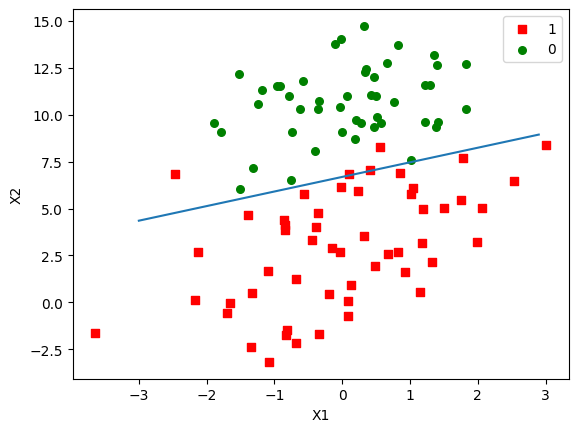

In [4]:
plotBestFit(gradAscent(dataArr, labelMat))

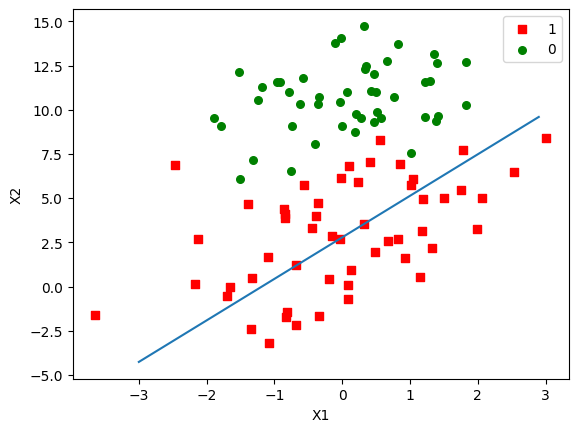

In [13]:
weight=stocGradAscent0(np.array(dataArr), labelMat)
plotBestFit(weight)

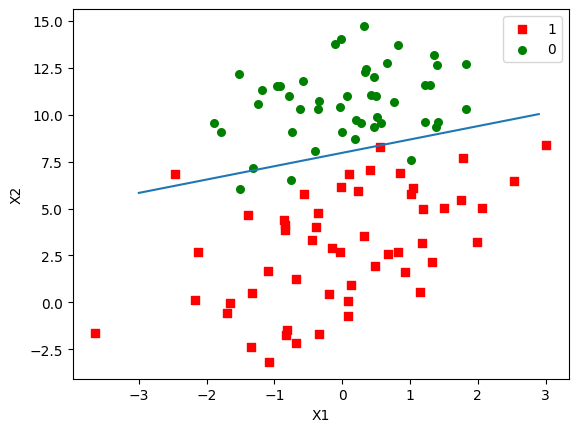

In [16]:
weights=stocGradAscent1(np.array(dataArr), labelMat)
plotBestFit(weights)

In [21]:
multiTest()

C:\Users\Jolene\AppData\Local\Temp\ipykernel_18620\132668508.py:14: RuntimeWarning: overflow encountered in exp
  return 1.0/(1+np.exp(-inX))


the error rate of this test is: 0.507463
the error rate of this test is: 0.328358
the error rate of this test is: 0.313433
the error rate of this test is: 0.313433
the error rate of this test is: 0.253731
the error rate of this test is: 0.328358
the error rate of this test is: 0.313433
the error rate of this test is: 0.313433
the error rate of this test is: 0.328358
the error rate of this test is: 0.268657
after 10 iterations the average error rate is: 0.326866
